# 03 — Flood Disruption: Hazard-Zone Proxy vs. Observed Sentinel-1 Extent

The central methodological comparison of this project. Full discussion in `../docs/sentinel1_derived_results.md`.

**Note:** an earlier version of this analysis also claimed the observed-vs-proxy damage difference was evidence of a network "chokepoint" mechanism. That claim was tested directly with a randomization null model and did not survive -- see notebook `06_robustness_checks_and_retraction.ipynb` and `../docs/robustness_checks.md` §7-7b. It is reported there as a retraction, not quietly dropped. The proxy-vs-observed comparison itself (this notebook) is unaffected and remains this project's most defensible finding.

In [1]:
import pickle
import numpy as np
import pandas as pd
import rasterio
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_RAW = Path('../data/raw')
DATA_PROC = Path('../data/processed')
province = gpd.read_file(DATA_RAW / 'kalsel_boundary.geojson')

## Disruption layers side by side

Left: BNPB InaRISK hazard-risk classification (general, multi-year). Right: Sentinel-1 SAR observed flood extent (the actual Jan 20, 2021 event).

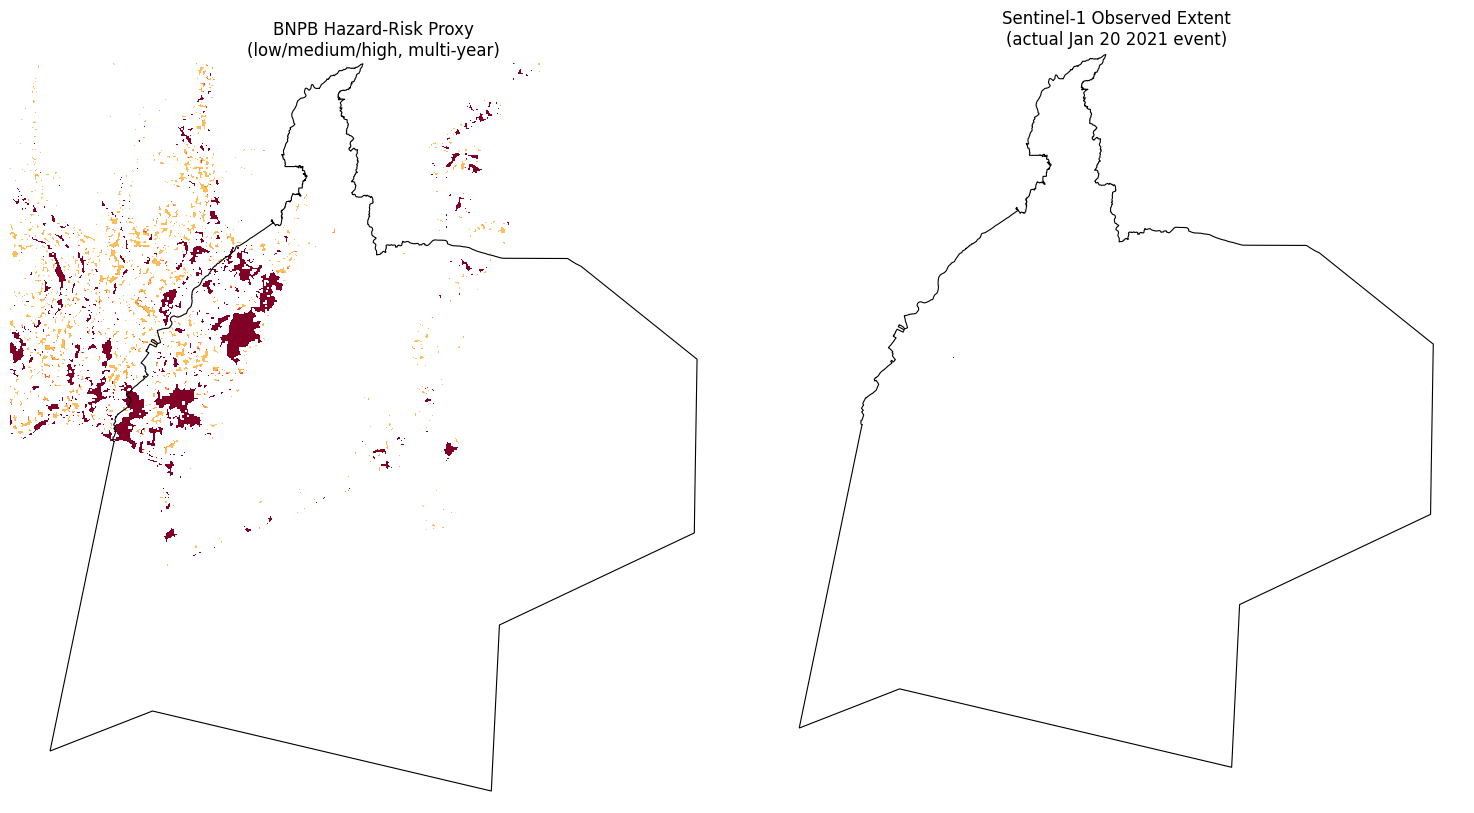

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(15, 8))

with rasterio.open(DATA_RAW / 'flood' / 'bnpb_kalsel_flood_hazard_class.tif') as src:
    hazard = src.read(1)
    extent1 = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
axes[0].imshow(np.ma.masked_equal(hazard, 0), extent=extent1, cmap='YlOrRd', vmin=0, vmax=3)
province.boundary.plot(ax=axes[0], color='black', linewidth=0.8)
axes[0].set_title('BNPB Hazard-Risk Proxy\n(low/medium/high, multi-year)')
axes[0].set_axis_off()

with rasterio.open(DATA_RAW / 'flood' / 'sentinel1_observed_flood_extent.tif') as src:
    flood = src.read(1)
    extent2 = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
axes[1].imshow(np.ma.masked_equal(flood, 0), extent=extent2, cmap='Blues', vmin=0, vmax=1)
province.boundary.plot(ax=axes[1], color='black', linewidth=0.8)
axes[1].set_title('Sentinel-1 Observed Extent\n(actual Jan 20 2021 event)')
axes[1].set_axis_off()
plt.tight_layout()
plt.show()

## Population-weighted access, all scenarios

In [3]:
scenarios = {
    'Baseline': DATA_PROC / 'baseline_travel_time.pickle',
    'Proxy — moderate': DATA_PROC / 'flood_disrupted_moderate_travel_time.pickle',
    'Proxy — severe': DATA_PROC / 'flood_disrupted_travel_time.pickle',
    'Sentinel-1 — moderate': DATA_PROC / 'flood_disrupted_sentinel1_moderate_travel_time.pickle',
    'Sentinel-1 — severe': DATA_PROC / 'flood_disrupted_sentinel1_travel_time.pickle',
}

import sys
sys.path.insert(0, '../src')
import importlib
mod = importlib.import_module('07_population_weighted_comparison')
from scipy.spatial import cKDTree

with open(DATA_PROC / 'kalsel_road_graph.pickle', 'rb') as f:
    G = pickle.load(f)
node_list = list(G.nodes())
tree = cKDTree(np.array(node_list))
xs, ys, pops = mod.load_population_points()
dist, idx = tree.query(np.column_stack([xs, ys]), k=1)
node_arr = np.array(node_list)
ok = dist <= 0.02
nodes_hit = [tuple(node_arr[i]) for i in idx[ok]]

rows = []
for label, path in scenarios.items():
    with open(path, 'rb') as f:
        tt = pickle.load(f)
    times = np.full(len(xs), np.nan)
    times[ok] = [tt.get(n, np.nan) for n in nodes_hit]
    valid = ~np.isnan(times)
    total = pops.sum()
    row = {'scenario': label}
    for t in [30, 60, 120]:
        within = pops[valid][times[valid] <= t].sum()
        row[f'within_{t}min_pct'] = 100 * within / total
    rows.append(row)

df = pd.DataFrame(rows).set_index('scenario')
df

,within_30min_pct,within_60min_pct,within_120min_pct
scenario,,,
Baseline,75.252142,81.000007,83.353724
Proxy — moderate,71.719349,79.441275,83.150373
Proxy — severe,43.112370,46.194107,47.963896
Sentinel-1 — moderate,71.035519,79.361750,82.849765
Sentinel-1 — severe,28.026086,30.407700,31.164941


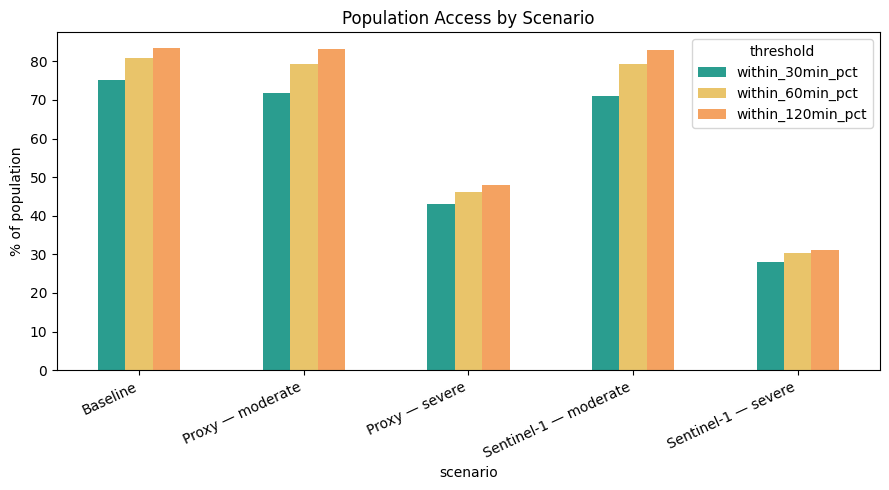

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
df.plot(kind='bar', ax=ax, color=['#2a9d8f', '#e9c46a', '#f4a261'])
ax.set_ylabel('% of population')
ax.set_title('Population Access by Scenario')
ax.legend(title='threshold')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

**Reading this chart:** the Sentinel-1 moderate scenario is the primary real-world estimate — a measured, plausible impact. The severe scenarios (both proxy and observed) are network-fragility stress tests, not literal population-affected claims; see `../docs/manuscript.md` §5.2 for why. The severe-scenario percentages shown here are the corrected figures: an earlier version of this pipeline had a pathing bug (Dijkstra restricted to the largest post-disruption fragment only), surfaced by `06`'s Null A2 check and fixed before these numbers were computed — see `../docs/robustness_checks.md` §7c. The proxy-vs-observed *comparison* direction (68.6% > 51.6% population disconnected) survives the fix unchanged.